In [228]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import interpolate
from sklearn import preprocessing as p

## Cleaning data

In [15]:
#importing data from Modulair MOD-00068
winddata = pd.read_csv('/home/pmg2147/ModulAir NMF/OceanRoof/MOD-00068-rawwithwind.csv').set_index('timestamp')
winddata.head()

,id,timestamp_local,sn,rh,temp,bin0,bin1,bin2,bin3,bin4,...,no2_diff,o3_we,o3_ae,ox_diff,co2_raw,flag,lat,lon,device_state,ws_scalar
timestamp,,,,,,,,,,,,,,,,,,,,,
2025-06-02T23:59:38Z,404246550,2025-06-02T19:59:38Z,MOD-00068,40.8,22.3,3.029,0.201,0.077,0.034,0.047,...,5.6,1658.0,1643.1,7.7,974.9,0,41.003887,-73.90551,ACTIVE,3.34
2025-06-02T23:58:38Z,404246548,2025-06-02T19:58:38Z,MOD-00068,40.7,22.3,3.078,0.240,0.067,0.009,0.018,...,6.1,1658.0,1643.0,8.1,974.1,0,41.003887,-73.90551,ACTIVE,3.37
2025-06-02T23:57:38Z,404246547,2025-06-02T19:57:38Z,MOD-00068,40.7,22.3,3.182,0.204,0.079,0.026,0.040,...,5.3,1658.0,1643.3,7.8,973.3,0,41.003887,-73.90551,ACTIVE,3.52
2025-06-02T23:56:38Z,404244206,2025-06-02T19:56:38Z,MOD-00068,40.6,22.4,2.921,0.279,0.100,0.008,0.046,...,5.6,1658.0,1643.3,8.0,973.4,0,41.003887,-73.90551,ACTIVE,2.96
2025-06-02T23:55:38Z,404244207,2025-06-02T19:55:38Z,MOD-00068,40.6,22.4,2.925,0.274,0.087,0.013,0.018,...,5.3,1657.9,1643.1,7.9,973.6,0,41.003887,-73.90551,ACTIVE,3.30


In [16]:
#only columns of interest
COLS_TO_INCLUDE = ['timestamp_local','wd','ws']
winddata = winddata[COLS_TO_INCLUDE]

winddata.head()

,timestamp_local,wd,ws
timestamp,,,
2025-06-02T23:59:38Z,2025-06-02T19:59:38Z,305.8,3.31
2025-06-02T23:58:38Z,2025-06-02T19:58:38Z,308.4,3.35
2025-06-02T23:57:38Z,2025-06-02T19:57:38Z,307.1,3.50
2025-06-02T23:56:38Z,2025-06-02T19:56:38Z,315.8,2.92
2025-06-02T23:55:38Z,2025-06-02T19:55:38Z,310.6,3.16


In [17]:
#removing the UTC time
winddata = winddata.reset_index(drop = True)
winddata.head()

,timestamp_local,wd,ws
0,2025-06-02T19:59:38Z,305.8,3.31
1,2025-06-02T19:58:38Z,308.4,3.35
2,2025-06-02T19:57:38Z,307.1,3.50
3,2025-06-02T19:56:38Z,315.8,2.92
4,2025-06-02T19:55:38Z,310.6,3.16


In [18]:
#converting to datetime
winddata['timestamp_local'] = pd.to_datetime(winddata['timestamp_local'], 
                                       format='%Y-%m-%dT%H:%M:%SZ',
                                       exact=False)
winddata.head()

,timestamp_local,wd,ws
0,2025-06-02 19:59:38,305.8,3.31
1,2025-06-02 19:58:38,308.4,3.35
2,2025-06-02 19:57:38,307.1,3.50
3,2025-06-02 19:56:38,315.8,2.92
4,2025-06-02 19:55:38,310.6,3.16


In [19]:
#taking hourly average of df. round to floor of the hour
winddata = winddata.groupby(winddata['timestamp_local'].dt.floor('h')).agg(wd = ('wd','mean'),
                                                                           ws = ('ws','mean')).reset_index()

winddata = winddata.round(decimals = 2)
winddata = winddata.dropna()
winddata

,timestamp_local,wd,ws
4532,2024-11-19 11:00:00,139.99,4.00
4533,2024-11-19 12:00:00,140.69,2.16
4534,2024-11-19 13:00:00,145.63,2.08
4535,2024-11-19 14:00:00,117.77,2.62
4536,2024-11-19 15:00:00,116.03,2.29
...,...,...,...
9215,2025-06-02 15:00:00,188.44,1.23
9216,2025-06-02 16:00:00,152.07,1.75
9217,2025-06-02 17:00:00,116.10,3.08
9218,2025-06-02 18:00:00,154.12,2.95


In [21]:
ts = pd.read_csv('/home/pmg2147/ModulAir NMF/OceanRoof/MOD-00068_timeseries_hourly.csv').drop(columns = 'Unnamed: 0')
ts.head()

,timestamp_local,co,no2,o3,no,bin0,bin1,bin2,bin3,bin4,bin5
0,2024-05-14 21:00:00,480.98,10.42,16.23,88.57,7.68,0.83,0.41,0.13,0.17,0.13
1,2024-05-14 22:00:00,474.06,9.65,11.91,67.56,7.21,0.75,0.37,0.12,0.16,0.12
2,2024-05-14 23:00:00,422.78,8.83,8.47,45.19,5.28,0.61,0.31,0.10,0.13,0.10
3,2024-05-15 00:00:00,274.73,11.20,9.15,32.63,3.86,0.33,0.16,0.05,0.07,0.05
4,2024-05-15 01:00:00,473.89,22.35,2.34,24.12,7.46,0.93,0.45,0.14,0.17,0.14


In [22]:
results = pd.read_csv('/home/pmg2147/ModulAir NMF/OceanRoof/4_factor_results.csv')
results.head()

,timestamp_local,Factor 1,Factor 2,Factor 3,Factor 4
0,2024-05-14 21:00:00,0.017150,0.038207,0.134333,0.007507
1,2024-05-14 22:00:00,0.016456,0.028775,0.130712,0.004313
2,2024-05-14 23:00:00,0.015469,0.020458,0.113285,0.000977
3,2024-05-15 00:00:00,0.018256,0.018183,0.066560,0.000000
4,2024-05-15 01:00:00,0.035816,0.003190,0.110893,0.008865


## Merging dataframes

In [23]:
data_1_2 = pd.merge(ts, results, on = 'timestamp_local', how = 'inner')
data_1_2

,timestamp_local,co,no2,o3,no,bin0,bin1,bin2,bin3,bin4,bin5,Factor 1,Factor 2,Factor 3,Factor 4
0,2024-05-14 21:00:00,480.98,10.42,16.23,88.57,7.68,0.83,0.41,0.13,0.17,0.13,0.017150,0.038207,0.134333,0.007507
1,2024-05-14 22:00:00,474.06,9.65,11.91,67.56,7.21,0.75,0.37,0.12,0.16,0.12,0.016456,0.028775,0.130712,0.004313
2,2024-05-14 23:00:00,422.78,8.83,8.47,45.19,5.28,0.61,0.31,0.10,0.13,0.10,0.015469,0.020458,0.113285,0.000977
3,2024-05-15 00:00:00,274.73,11.20,9.15,32.63,3.86,0.33,0.16,0.05,0.07,0.05,0.018256,0.018183,0.066560,0.000000
4,2024-05-15 01:00:00,473.89,22.35,2.34,24.12,7.46,0.93,0.45,0.14,0.17,0.14,0.035816,0.003190,0.110893,0.008865
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8290,2025-06-02 15:00:00,126.50,20.10,42.42,3.08,1.76,0.10,0.03,0.01,0.01,0.01,0.030311,0.070075,0.000000,0.000328
8291,2025-06-02 16:00:00,156.38,20.30,43.08,2.62,1.81,0.11,0.03,0.01,0.01,0.01,0.031239,0.071914,0.003017,0.000000
8292,2025-06-02 17:00:00,180.38,32.70,44.03,2.27,1.99,0.12,0.04,0.01,0.01,0.01,0.049614,0.068957,0.000000,0.000037
8293,2025-06-02 18:00:00,194.86,34.17,43.88,3.08,2.23,0.13,0.04,0.01,0.02,0.01,0.052101,0.068657,0.000000,0.000512


In [29]:
data_1_2['timestamp_local'] = pd.to_datetime(data_1_2['timestamp_local'])

In [30]:
data = pd.merge(data_1_2, winddata, on = 'timestamp_local', how = 'inner')
data

,timestamp_local,co,no2,o3,no,bin0,bin1,bin2,bin3,bin4,bin5,Factor 1,Factor 2,Factor 3,Factor 4,wd,ws
0,2024-11-19 11:00:00,143.60,10.28,31.03,3.73,1.92,0.08,0.02,0.01,0.01,0.01,0.016129,0.053736,0.016530,0.000000,139.99,4.00
1,2024-11-19 13:00:00,120.02,20.00,34.43,2.84,1.52,0.08,0.03,0.01,0.01,0.01,0.030296,0.055849,0.000000,0.000514,145.63,2.08
2,2024-11-19 15:00:00,151.21,27.41,33.30,3.01,1.77,0.08,0.02,0.01,0.01,0.01,0.041731,0.051606,0.000000,0.000315,116.03,2.29
3,2024-11-19 16:00:00,176.06,29.38,32.28,3.10,2.24,0.09,0.03,0.01,0.01,0.01,0.045171,0.049657,0.001903,0.000000,104.98,2.29
4,2024-11-19 17:00:00,198.93,30.22,31.55,2.99,2.65,0.12,0.04,0.01,0.02,0.01,0.046592,0.048265,0.007642,0.000000,74.86,2.59
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4366,2025-06-02 15:00:00,126.50,20.10,42.42,3.08,1.76,0.10,0.03,0.01,0.01,0.01,0.030311,0.070075,0.000000,0.000328,188.44,1.23
4367,2025-06-02 16:00:00,156.38,20.30,43.08,2.62,1.81,0.11,0.03,0.01,0.01,0.01,0.031239,0.071914,0.003017,0.000000,152.07,1.75
4368,2025-06-02 17:00:00,180.38,32.70,44.03,2.27,1.99,0.12,0.04,0.01,0.01,0.01,0.049614,0.068957,0.000000,0.000037,116.10,3.08
4369,2025-06-02 18:00:00,194.86,34.17,43.88,3.08,2.23,0.13,0.04,0.01,0.02,0.01,0.052101,0.068657,0.000000,0.000512,154.12,2.95


## Plots

In [60]:
wd_rad = np.radians(np.array(data['wd'])) #deg to rad
ws = np.array(data['ws']) #m/s
Factor1 = np.array(data['Factor 1'])
Factor2 = np.array(data['Factor 2'])
Factor3 = np.array(data['Factor 3'])
Factor4 = np.array(data['Factor 4'])

In [67]:
WD, WS = np.meshgrid(np.linspace(0, 2*np.pi, 36), np.linspace(min(ws), max(ws), 16 ))
Z1 = interpolate.griddata((wd_rad, ws), Factor1, (WD, WS), method='linear')
Z2 = interpolate.griddata((wd_rad, ws), Factor2, (WD, WS), method='linear')
Z3 = interpolate.griddata((wd_rad, ws), Factor3, (WD, WS), method='linear')
Z4 = interpolate.griddata((wd_rad, ws), Factor4, (WD, WS), method='linear')

Z1 = np.nan_to_num(Z1, nan=1e-3)
Z2 = np.nan_to_num(Z2, nan=1e-3)
Z3 = np.nan_to_num(Z3, nan=1e-3)
Z4 = np.nan_to_num(Z4, nan=1e-3)

In [121]:
maxima = [np.max(i) for i in [Z1,Z2,Z3,Z4]]
maxima

[0.06460775093445043,
 0.08375844473974502,
 0.1302385635771175,
 0.26641386900817854]

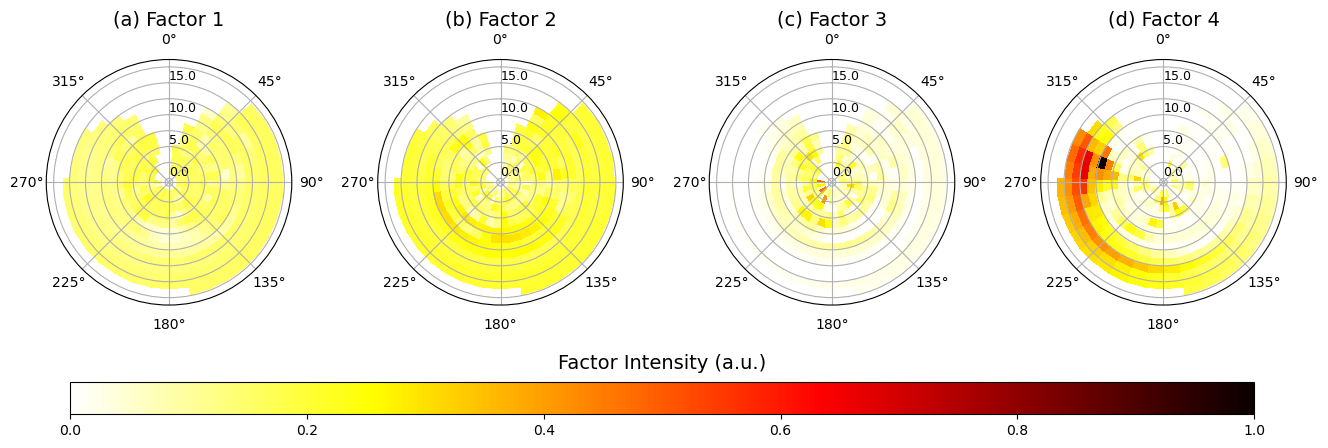

In [276]:
# set up the matplotlib figure
fig, ax = plt.subplots(nrows=1, ncols=4, figsize=(16, 16), subplot_kw={'projection': 'polar'})
plt.subplots_adjust(wspace=0.35)
cmap = plt.get_cmap('hot_r')
cmap.set_under('none')

#change set-up to compass bearings
for i in range(4):
    ax[i].set_theta_zero_location('N')
    ax[i].set_theta_direction(-1)

#label
ax[0].set_title('(a) Factor 1',fontsize=14)
ax[1].set_title('(b) Factor 2',fontsize=14)
ax[2].set_title('(c) Factor 3',fontsize=14)
ax[3].set_title('(d) Factor 4',fontsize=14)

#plot
img1 = ax[0].pcolormesh(WD, WS, Z1, cmap=cmap, vmax = np.max(Z4))
img2 = ax[1].pcolormesh(WD, WS, Z2, cmap=cmap, vmax = np.max(Z4))
img3 = ax[2].pcolormesh(WD, WS, Z3, cmap=cmap, vmax = np.max(Z4))
img4 = ax[3].pcolormesh(WD, WS, Z4, cmap=cmap, vmax = np.max(Z4))

#label radial ticks
for i in range(4):
    ax[i].tick_params(axis='y', which='major', labelsize=9)
    ax[i].set_rticks([0,2.5,5,7.5,10,12.5,15,17.5])
    ax[i].set_rlabel_position(0)
    ax[i].set_yticklabels(['0.0','','5.0','','10.0','','15.0',''])

#set colorbar
cbar_ax = fig.add_axes([0.14, 0.35, 0.74, 0.02])
cbar = fig.colorbar(img4, cax=cbar_ax, orientation='horizontal')
cbar.set_ticks(list(np.linspace(0, np.max(Z4), 6)))
cbar.set_ticklabels([0.0,0.2,0.4,0.6,0.8,1.0])
cbar.set_label('Factor Intensity (a.u.)', labelpad = 10, fontsize = 14)
cbar.ax.xaxis.set_label_position('top')

#fig.savefig('/home/pmg2147/ModulAir NMF/OceanRoof/windrose_MOD-00068.png')